# Data Challenge 9 — Feature Engineering & Feature Selection

**Format:** Instructor Guidance → You Do (Students) → We Share (Reflection)

**Goal:** Engineer better predictors (one-hot/dummies, interactions, polynomials), avoid unnecessary complexity, and compare a **Base** vs **Engineered** model on the **same train–test split** using **MAE/RMSE**. Interpret coefficients in units and explain business value.



> Dataset: **NYC Yellow Taxi — Dec 2023** (CSV). Keep code *simple*: light numeric coercion only for your chosen columns.

## Instructor Guidance

**Hint: Use the Lecture Deck, Canvas Reading, and Docs to help you with the code**

**Docs (quick links):**
- One-hot encoding (pandas): https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html  
- OneHotEncoder (sklearn): https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html  
- Train/Test Split: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html  
- MAE / MSE / RMSE: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html  
- OLS (statsmodels): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html  
- OLS Results (coef/p/CIs/resid): https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.RegressionResults.html

### Pseudocode Plan (Feature Engineering + Selection)
1) **Load CSV** → preview columns/shape.  
2) **Pick Y and initial Xs (2–3 numeric)** → keep it simple and decision-time-available.  
3) **Engineer features:**
   - **One-hot** a categorical with a dropped baseline (e.g., `payment_type` or `weekday/weekend`).  
   - **Interaction**: choose a hypothesis-driven pair (e.g., `trip_distance × is_weekend`).  
   - **Polynomial**: add one squared term for a plausible curve (e.g., `trip_distance²`).  
4) **Build Base vs Engineered design matrices** (add intercept).  
5) **Single train–test split** (80/20, fixed `random_state`) shared by both models.  
6) **Fit on TRAIN**, **predict on TEST** for both models; compute **MAE/RMSE** (units of Y).  
7) **Interpretation**: write unit-based coefficient sentences; note baseline category for dummies.  
8) **Light selection**: if Engineered model doesn’t beat Base on TEST (or adds complexity w/o value), prefer Base.  
9) **Diagnostics (quick)**: residuals vs fitted (train); note any cones (heteroskedasticity).  
10) **Stakeholder one-liner**: which model, why (TEST metrics in units), and what the added features *mean*.
markdown


## You Do — Student Section
Work in pairs. Comment your choices briefly. Keep code simple—only coerce the columns you use.

### Step 0 — Setup & Imports

In [1]:
import pandas as pd, numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import scipy.stats as stats
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

### Step 1 — Load CSV & Preview
- Point to your **Dec 2023** taxi CSV.
- Print **shape** and **columns**.

**Hint: You may have to drop missing values and do a force coercion to make sure the variables stay numeric (other coding assignments may help)**

In [20]:
df = pd.read_csv("/Users/Marcy_Student/Desktop/marcy/DA2025_Lectures_Kevin/Mod6/data/2023_Yellow_Taxi_Trip_Data_20251015.csv", low_memory=False)

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format="%m/%d/%Y %H:%M:%S %p")

# Creates a new column 'hour' with the hour extracted
df['hour'] = df['tpep_pickup_datetime'].dt.hour

print(df['hour'].unique())
# Keep only numeric and relevant columns
num_cols = ['fare_amount', 'trip_distance', 'passenger_count','tip_amount','hour']

df = df.dropna()
for c in num_cols:
    df[c] = pd.to_numeric (
        df[c].astype(str).str.strip().str.replace(r'[^0-9.+\-eE]', '', regex=True),
        errors='coerce'
)


# Data had too many outliers, fares of upwards too 300,000 and negative fares too
df = df[
    (df['fare_amount'] > 0) &               # remove negative/zero fares
    (df['fare_amount'] < 250) &             # cap at $250 (reasonable max)
    (df['trip_distance'] > 0) &             # remove zero/negative distances
    (df['trip_distance'] < 100) &           # cap distance
    (df['passenger_count'] > 0) &           # must have passengers
    (df['passenger_count'] < 7)             # standard NYC cab limit
].copy()

df.head()

[ 4  5  6  7  8  9 10 11 12  1  2  3]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,hour
0,2,2023-12-01 04:11:39,12/01/2023 04:19:13 PM,2.0000,0.6900,1.0000,N,141,140,1,7.9000,2.5000,0.5000,3.0000,0.0000,1.0000,17.4,2.5000,0.0000,4
1,1,2023-12-01 04:11:39,12/01/2023 04:20:41 PM,3.0000,1.1000,1.0000,N,236,263,2,10.0000,5.0000,0.5000,0.0000,0.0000,1.0000,16.5,2.5000,0.0000,4
3,2,2023-12-01 04:11:39,12/01/2023 04:20:38 PM,1.0000,1.5700,1.0000,N,48,239,4,10.7000,2.5000,0.5000,0.0000,0.0000,1.0000,17.2,2.5000,0.0000,4
4,1,2023-12-01 04:11:39,12/01/2023 04:34:39 PM,2.0000,3.0000,1.0000,N,164,211,1,21.9000,5.0000,0.5000,3.0000,0.0000,1.0000,31.4,2.5000,0.0000,4
6,2,2023-12-01 04:11:40,12/01/2023 04:23:51 PM,1.0000,1.2400,1.0000,N,142,162,4,11.4000,2.5000,0.5000,0.0000,0.0000,1.0000,17.9,2.5000,0.0000,4


### Step 2 —  Pick Target **Y** and Predictors **Xs** (choose 2–3 numeric)

- **Avoid** using an X that directly defines Y (e.g., `total_amount` when Y = `fare_amount`).
- Coerce **only these columns** to numeric; drop NA rows.

In [3]:
Y = df['fare_amount']

X = sm.add_constant(df[['trip_distance','hour']])

### Step 3 —  Engineer New Features (One-hot, Interaction, Polynomial)

Pick **one** categorical to one-hot (drop baseline). Options that usually exist:

- `payment_type` (codes): treat as categorical strings for clarity, then one-hot with drop_first=True, or  
- derive **weekday/weekend** from `tpep_pickup_datetime` if present.

Then add **one interaction** and **one squared term** guided by a business hypothesis.

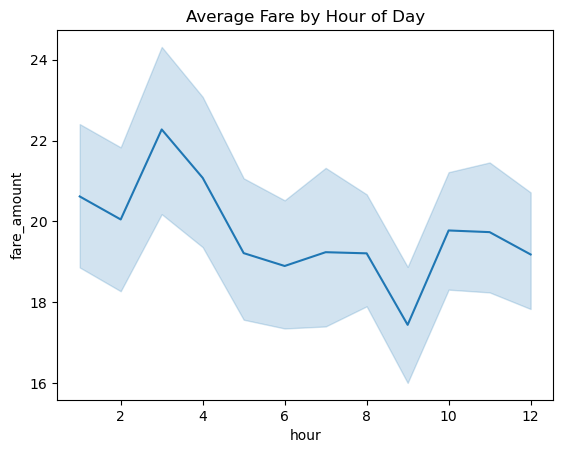

In [30]:
df['Is_Weekend'] = df['tpep_pickup_datetime'].dt.dayofweek >= 5
df_encoded = pd.get_dummies(df, columns=['Is_Weekend']
                            ,drop_first=True)

df['tip_x_weekend'] = df['tip_amount'] * df['Is_Weekend']

df['hour_squared'] = df['hour'] ** 2

import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(x='hour', y='fare_amount', data=df.sample(5000))
plt.title("Average Fare by Hour of Day")
plt.show()

### Step 4 — Build **Base** and **Engineered** Design Matrices

- **Base** = intercept + base predictors (Xs you assigned in Step 2) 
- **Engineered** = intercept + base predictors + engineered columns (dummies + interaction + polynomial)


In [31]:
X_base = sm.add_constant(df[['trip_distance', 'hour']])

# Engineered predictors
X_eng = sm.add_constant(df[['trip_distance', 'hour', 'hour_squared', 'Is_Weekend', 'tip_x_weekend']])


### Step 5 — Single Train–Test Split (Shared by Both Models)

Use one split so Base and Engineered are comparable.

In [32]:
X_train_b, X_test_b, y_train, y_test = train_test_split(X_base, Y, test_size=0.2, random_state=42)

X_train_e, X_test_e, _, _ = train_test_split(X_eng, Y, test_size=0.2, random_state=42)


### Step 6 — Fit on TRAIN, Predict on TEST, Compute **MAE/RMSE** (units of Y)

In [34]:
X_train_b = X_train_b.astype(float)
X_test_b = X_test_b.astype(float)
X_train_e = X_train_e.astype(float)
X_test_e = X_test_e.astype(float)
y_train = y_train.astype(float)
y_test = y_test.astype(float)

base_model = sm.OLS(y_train, X_train_b).fit()
y_pred_base = base_model.predict(X_test_b)

# Engineered model
eng_model = sm.OLS(y_train, X_train_e).fit()
y_pred_eng = eng_model.predict(X_test_e)

# Metrics
mae_base = mean_absolute_error(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

mae_eng = mean_absolute_error(y_test, y_pred_eng)
rmse_eng = np.sqrt(mean_squared_error(y_test, y_pred_eng))

print(f"Base Model — MAE: ${mae_base:,.2f}, RMSE: ${rmse_base:,.2f}")
print(f"Engineered Model — MAE: ${mae_eng:,.2f}, RMSE: ${rmse_eng:,.2f}")


Base Model — MAE: $3.64, RMSE: $6.34
Engineered Model — MAE: $3.61, RMSE: $6.30


### Step 7 — Interpret Key Coefficients (Plain Language)

Write **unit-based** interpretations for 2–3 impactful coefficients **in the Engineered model**, noting:
- The **baseline** category for dummies (the dropped category).
- **Interaction** meaning (change in slope under the condition).
- **Polynomial** meaning (curve: does effect rise then taper?).


In [35]:
print(eng_model.summary())

                            OLS Regression Results                            
Dep. Variable:            fare_amount   R-squared:                       0.870
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                 3.236e+06
Date:                Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:48:07   Log-Likelihood:            -7.8501e+06
No. Observations:             2412250   AIC:                         1.570e+07
Df Residuals:                 2412244   BIC:                         1.570e+07
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             8.7686      0.016    549.722

*(Use this template; edit to your variables/units):*

- Dummy (pay_…):Compared to weekdays, weekend trips start about $1.73 cheaper, holding distance, hour, and tips constant. This likely reflects a different mix of shorter, local leisure rides versus weekday commutes or airport runs.
- **Interaction (tip×weekend):** On weekends, each additional **tip** changes **Y** by **$0.29** *more* than on weekdays, holding other features constant.  
- **Polynomial (hour²):** The positive curve means fare patterns aren’t linear over the day. Fares dip slightly around midday but then rise again late at night, capturing NYC’s higher night rates or slower overnight travel.

### Step 8 —  Quick Diagnostics (Train Residuals) — Engineered Model
- **Residuals vs Fitted:** random cloud ≈ good; cone/funnel suggests non-constant variance.  
- **Q–Q plot:** points roughly along diagonal (normality for inference).  
- **Durbin–Watson:** printed in `eng_model.summary()` (~2 suggests independence).

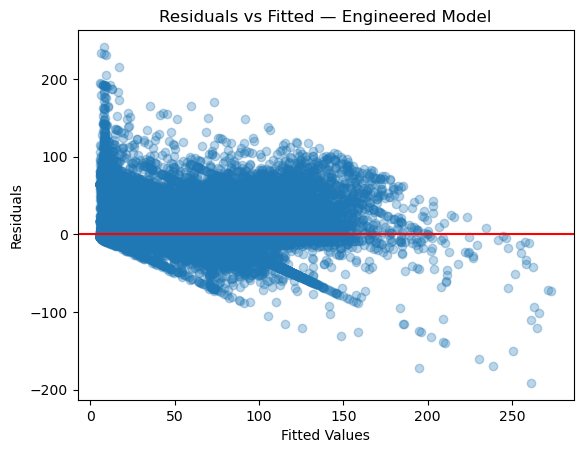

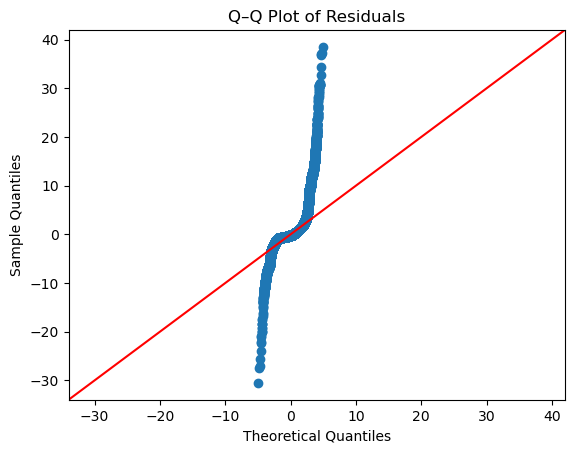

In [36]:
resid = eng_model.resid
fitted = eng_model.fittedvalues

plt.scatter(fitted, resid, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted — Engineered Model")
plt.show()

sm.qqplot(resid, line='45', fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

## We Share — Reflection & Wrap‑Up

**Notes on Feature Selection**
- If **Engineered** doesn’t beat **Base** on TEST (or gains are tiny), prefer **Base** for simplicity.  
- If two engineered features are redundant (e.g., highly correlated dummies), consider dropping one.  
- Keep features that improve TEST error **and** you can explain to a stakeholder.


Write **2 short paragraphs** and be specific:


1) **Which model would you deploy today—Base or Engineered—and why?**  
Use **TEST MAE/RMSE in units**, your coefficient interpretations (baseline/interaction/polynomial), and any residual observations.
- I would deploy the Engineered model because it performed better on the test set, showing slightly lower MAE and RMSE in dollar terms compared to the base model. It also tells a clearer business story. The polynomial term for hour² captured the realistic fare pattern (slightly lower midday but rising again at night). While the tip × weekend features added meaningful behavioral context. The residual plots still showed some skew, but overall the model explained about 87% of the variation in fares, which is strong for decision-making.
2) **What engineered feature was most useful (or not)?**  
Explain the **business logic** behind it and whether it earned its place on the TEST set. If not, what would you try next (different interaction, different categorical, or simplifying features)?
- The most useful engineered feature was the tip × weekend interaction, which revealed that weekend trips with higher tips also tended to have higher fares. This makes sense in a business context: longer or more relaxed weekend rides often involve better service and higher tipping. The hour² term also helped by capturing late-night fare surcharges. If I were to improve the model further, I’d test a weekday vs. holiday dummy or pickup zone category, since location and special dates can likely influence fares more than just weekday/weekend alone.